# **Assignment 2**

###### Iman Chaudhry

In [268]:
# imports
import time
import cv2
import numpy as np
from matplotlib import pyplot as plt
from collections import deque

# load image
lena = cv2.imread('lena.tif', cv2.IMREAD_GRAYSCALE)

## Task 1

*Implement from scratch the convolution operations for*

* An averaging smoothing filter (filter size: `3*3`)
* A Gaussian smoothing filter (filter size: `7*7`, sigma=`1`, mean=`0`)
* The Sobel sharpening filter (filter size: `3*3`, both horizontal and vertical)

_Convolutional Operation Helper Function_

In [269]:
def convolution(img, kernel):
    img_h, img_w = img.shape
    kernel_h, kernel_w = kernel.shape
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    padded_image = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(img_h):
        for j in range(img_w):
            region = padded_image[i:i + kernel_h, j:j + kernel_w]
            output[i, j] = np.sum(region * kernel)

    return output.astype(np.uint8)

### Part A:
_An averaging smoothing filter (filter size: `3*3`)_

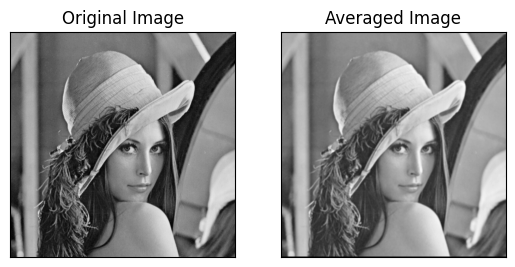

In [270]:
def average_filter(img, kernel_size):
    m, n = img.shape
    mask = np.ones(kernel_size, dtype=np.float32) / (kernel_size[0] * kernel_size[1])
    avg_image = np.zeros((m, n), dtype=np.float32)
    
    for i in range(1, m-1):
        for j in range(1, n-1):
            temp = (img[i-1, j-1] * mask[0, 0] +
                    img[i-1, j] * mask[0, 1] +
                    img[i-1, j + 1] * mask[0, 2] +
                    img[i, j-1] * mask[1, 0] +
                    img[i, j] * mask[1, 1] +
                    img[i, j + 1] * mask[1, 2] +
                    img[i + 1, j-1] * mask[2, 0] +
                    img[i + 1, j] * mask[2, 1] +
                    img[i + 1, j + 1] * mask[2, 2])
            avg_image[i, j] = temp
            
    return avg_image.astype(np.uint8)

avg_img = average_filter(lena, (3,3))
cv2.imwrite(f"t1a.tif", avg_img)

# display
plt.subplot(121), plt.imshow(lena, cmap='gray'), plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(avg_img, cmap='gray'), plt.title('Averaged Image'), plt.xticks([]), plt.yticks([])
plt.show()

### Part B:
_A Gaussian smoothing filter (filter size: `7*7`, sigma=`1`, mean=`0`)_

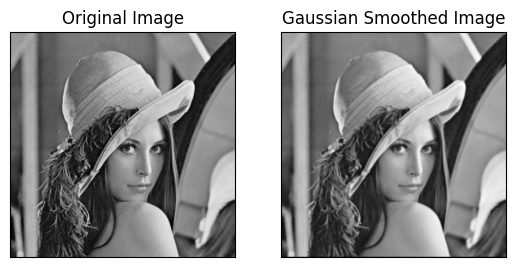

In [271]:
def gaussian_filter(sigma, filter_size):
    m, n = filter_size
    m_half = m // 2
    n_half = n // 2
    gaussian_filter = np.zeros((m, n), np.float32)

    for y in range(-m_half, m_half + 1):
        for x in range(-n_half, n_half + 1):
            normal = 1 / (2.0 * np.pi * sigma**2.0)
            exp_term = np.exp(-(x**2.0 + y**2.0) / (2.0 * sigma**2.0))
            gaussian_filter[y + m_half, x + n_half] = normal * exp_term

    gaussian_filter /= gaussian_filter.sum()
    return gaussian_filter

filter = gaussian_filter(1, (7, 7))
gaussian_img = convolution(lena, filter)
cv2.imwrite(f"t1b.tif", gaussian_img)

# display
plt.subplot(1, 2, 1), plt.imshow(lena, cmap='gray'), plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(gaussian_img, cmap='gray'), plt.title('Gaussian Smoothed Image'), plt.xticks([]), plt.yticks([])
plt.show()



### Part C:
_The Sobel sharpening filter (filter size: `3*3`, both horizontal and vertical)_

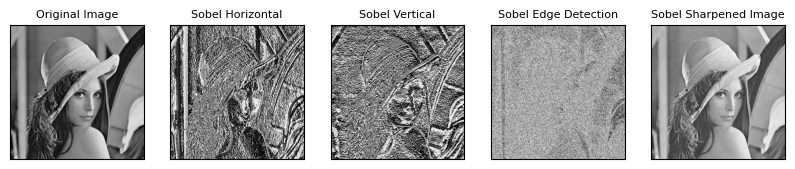

In [272]:
def sobel_sharpen(image):
    sobel_x = np.array([[-1, 0, 1], 
                        [-2, 0, 2], 
                        [-1, 0, 1]])
    sobel_y = np.flip(sobel_x.T, axis=0)

    sobel_imagex = convolution(image, sobel_x)
    sobel_imagey = convolution(image, sobel_y)
    
    magnitude = np.sqrt(sobel_imagex**2 + sobel_imagey**2)
    sharpened_image = image + magnitude.astype(np.uint8)
    
    return sobel_imagex, sobel_imagey, sharpened_image, magnitude.astype(np.uint8)

sx, sy, sharpened_image, magnitude = sobel_sharpen(lena)
sharpened_image = np.clip(sharpened_image + magnitude, 0, 255).astype(np.uint8)
cv2.imwrite(f"t1c.tif", sharpened_image)

cv2.imwrite(f"t1c-x.tif", sx)
cv2.imwrite(f"t1c-y.tif", sy)
cv2.imwrite(f"t1c-edge.tif", magnitude)

# display
plt.figure(figsize=(10, 5))
plt.subplot(1, 5, 1), plt.imshow(lena, cmap='gray'), plt.title('Original Image', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 2), plt.imshow(sx, cmap='gray'), plt.title('Sobel Horizontal', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 3), plt.imshow(sy, cmap='gray'), plt.title('Sobel Vertical', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 4), plt.imshow(magnitude, cmap='gray'), plt.title('Sobel Edge Detection', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 5), plt.imshow(sharpened_image, cmap='gray'), plt.title('Sobel Sharpened Image', fontsize=8), plt.xticks([]), plt.yticks([])
plt.show()

## Task 2

*Use the OpenCV built-in functions for*

* An averaging smoothing filter (filter size: `3*3`)
* A Gaussian smoothing filter (filter size: `7*7`, sigma=`1`, mean=`0`)
* The Sobel sharpening filter (filter size: `3*3`, both horizontal and vertical)


### Part A
_An averaging smoothing filter (filter size: `3*3`)_

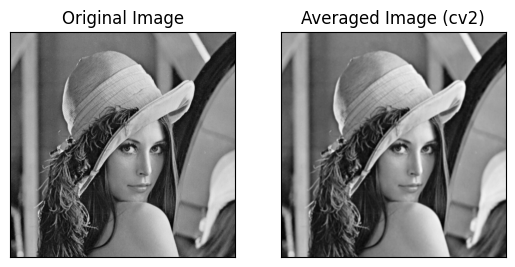

In [273]:
kernel_sizeA = (3,3)
avg_filter = np.ones(kernel_sizeA, np.float32) / (kernel_sizeA[0] * kernel_sizeA[1])
avg_img_opencv = cv2.filter2D(lena, -1, avg_filter)
cv2.imwrite(f"t2a.tif", avg_img_opencv)

# display
plt.subplot(121), plt.imshow(lena, cmap='gray'), plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(avg_img_opencv, cmap='gray'), plt.title('Averaged Image (cv2)'), plt.xticks([]), plt.yticks([])
plt.show()

### Part B
_A Gaussian smoothing filter (filter size: `7*7`, sigma=`1`, mean=`0`)_

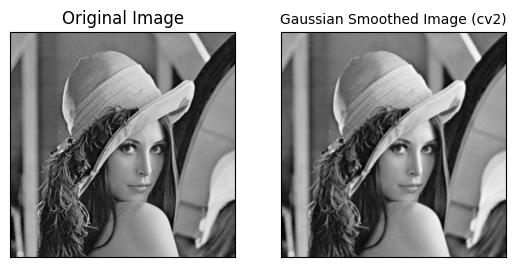

In [274]:
kernel_sizeB = (7,7)
sigma = 1
gaussian_img_opencv = cv2.GaussianBlur(lena, kernel_sizeB, sigma)
cv2.imwrite(f"t2b.tif", gaussian_img_opencv)

# display
plt.subplot(1, 2, 1), plt.imshow(lena, cmap='gray'), plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(gaussian_img_opencv, cmap='gray'), plt.title('Gaussian Smoothed Image (cv2)', fontsize=10), plt.xticks([]), plt.yticks([])
plt.show()

### Part C:
_The Sobel sharpening filter (filter size: `3*3`, both horizontal and vertical)_

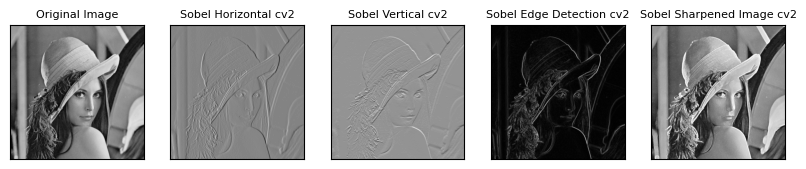

In [275]:
sobel_x_opencv = cv2.Sobel(lena, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_opencv = cv2.Sobel(lena, cv2.CV_64F, 0, 1, ksize=3)

magnitude_opencv = np.sqrt(sobel_x_opencv**2 + sobel_y_opencv**2)
magnitude_opencv = cv2.normalize(magnitude_opencv, None, 0, 255, cv2.NORM_MINMAX)
sharpened_image_opencv = lena + magnitude_opencv
sharpened_image_opencv = np.clip(sharpened_image_opencv, 0, 255)

cv2.imwrite(f"t2c.tif", sharpened_image_opencv)
cv2.imwrite(f"t2c-x.tif", sobel_x_opencv)
cv2.imwrite(f"t2c-y.tif", sobel_y_opencv)
cv2.imwrite(f"t2c-edge.tif", magnitude_opencv)

# display
plt.figure(figsize=(10, 5))
plt.subplot(1, 5, 1), plt.imshow(lena, cmap='gray'), plt.title('Original Image', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 2), plt.imshow(sobel_x_opencv, cmap='gray'), plt.title('Sobel Horizontal cv2', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 3), plt.imshow(sobel_y_opencv, cmap='gray'), plt.title('Sobel Vertical cv2', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 4), plt.imshow(magnitude_opencv, cmap='gray'), plt.title('Sobel Edge Detection cv2', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 5, 5), plt.imshow(sharpened_image_opencv, cmap='gray'), plt.title('Sobel Sharpened Image cv2', fontsize=8), plt.xticks([]), plt.yticks([])
plt.show()

## Task 3

*Use the OpenCV built-in functions for*

* The Marr-Hildreth edge detector
* The Canny edge detector

### Part A:
_The Marr-Hildreth Edge Detector_

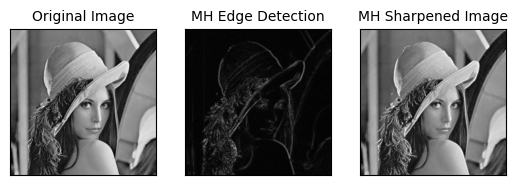

In [276]:
smoothed = cv2.GaussianBlur(lena, (5, 5), 1.0)
laplacian = cv2.Laplacian(smoothed, cv2.CV_64F)
laplacian_abs = np.absolute(laplacian)
marr_hildreth_e = cv2.convertScaleAbs(laplacian_abs)
c = 2
marr_hildreth = cv2.add(lena, marr_hildreth_e * 2)
cv2.imwrite(f"t3a.tif", marr_hildreth_e)

# display
plt.subplot(1, 3, 1), plt.imshow(lena, cmap='gray'), plt.title('Original Image', fontsize=10), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 2), plt.imshow(marr_hildreth_e, cmap='gray'), plt.title('MH Edge Detection', fontsize=10), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 3), plt.imshow(marr_hildreth, cmap='gray'), plt.title('MH Sharpened Image', fontsize=10), plt.xticks([]), plt.yticks([])
plt.show()

### Part B:
_The Canny Edge Detector_

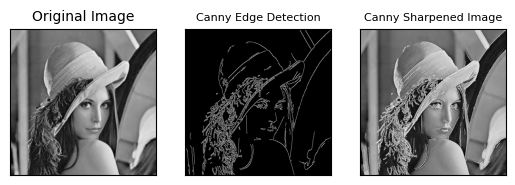

In [277]:
canny_e = cv2.Canny(lena, 100, 200)
g_canny = cv2.add(lena, canny_e * c)
g_canny = np.clip(g_canny, 0, 255).astype(np.uint8)
cv2.imwrite(f"t3b.tif", canny_e)

# display
plt.subplot(1, 3, 1), plt.imshow(lena, cmap='gray'), plt.title('Original Image', fontsize=10), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 2), plt.imshow(canny_e, cmap='gray'), plt.title('Canny Edge Detection', fontsize=8), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 3), plt.imshow(g_canny, cmap='gray'), plt.title('Canny Sharpened Image', fontsize=8), plt.xticks([]), plt.yticks([])
plt.show()

## Task 4

_Implement from scratch the algorithm to group adjacent pixels in an edge map, as given in the “Edge Detection” lecture slides. Apply your algorithms on the edge maps generated using Tasks **3A** and **3B** and mark different connected regions in different colours_

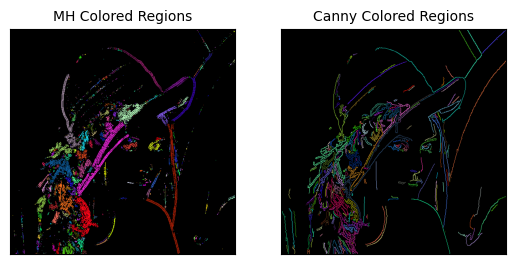

In [278]:
# deque faster/more memory efficient than queue ex, O(1) vs O(n) T(n)

def group_adj(edge_map):
    labels = np.zeros_like(edge_map, dtype=int)
    rows, cols = edge_map.shape
    # first pixel in image
    curlab = 1

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), 
                  (-1, -1), (-1, 1), (1, -1), (1, 1)]

    for r in range(rows):
        for c in range(cols):
            # if it's a foreground pixel and not labeled yet
            if edge_map[r, c] == 1 and labels[r, c] == 0:
                # pop element / deque 
                labels[r, c] = curlab
                queue = deque([(r, c)])

                # process bfs
                while queue:
                    cr, cc = queue.popleft()
                    for dr, dc in directions:
                        nr, nc = cr + dr, cc + dc
                        if 0 <= nr < rows and 0 <= nc < cols:  # boundaries check
                            if edge_map[nr, nc] == 1 and labels[nr, nc] == 0:
                                labels[nr, nc] = curlab
                                queue.append((nr, nc))
                # increment
                curlab += 1

    return labels


def colour(labels):
    num_labels = labels.max()
    h, w = labels.shape
    color_map = np.zeros((h, w, 3), dtype=np.uint8)
    colors = {label: [int(x) for x in np.random.randint(0, 255, size=3)] for label in range(1, num_labels+1)}
    
    for r in range(h):
        for c in range(w):
            label = labels[r, c]
            if label > 0:
                color_map[r, c] = colors[label]
    return color_map

# conv
canny_e = (canny_e > 0).astype(np.uint8)
marr_hildreth_e = (marr_hildreth_e > 10).astype(np.uint8)

# marr hildreth (T3A)
MH_labels = group_adj(marr_hildreth_e)
MH_colour = colour(MH_labels)
cv2.imwrite(f"t4a.tif", MH_colour)

# canny (T3B)
canny_labels = group_adj(canny_e)
canny_colour = colour(canny_labels)
cv2.imwrite(f"t4b.tif", canny_colour)

# display
plt.subplot(1, 2, 1), plt.imshow(MH_colour), plt.title('MH Colored Regions', fontsize=10), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(canny_colour), plt.title('Canny Colored Regions', fontsize=10), plt.xticks([]), plt.yticks([])
plt.show()



## BONUS Task

_Make a table to compare the efficiency of from-scratch methods and OpenCV. For each task, enter the computation time for your implementation, OpenCV implementation, and the difference between the two._

In [279]:
# Task 1: Average Filter
start = time.time()
avg_img_scratch = average_filter(lena, (3,3))
avg_time_scratch = time.time() - start

start = time.time()
avg_img_opencv = cv2.filter2D(lena, -1, np.ones((3,3), np.float32) / 9)
avg_time_opencv = time.time() - start

# Task 2: Gaussian Filter
start = time.time()
filter = gaussian_filter(1, (7, 7))
gaussian_img = convolution(lena, filter)
gaussian_time_scratch = time.time() - start

start = time.time()
gaussian_img_opencv = cv2.GaussianBlur(lena, (7, 7), 1)
gaussian_time_opencv = time.time() - start

# Task 3: Sobel Filter
start = time.time()
x, y, sharpened_image, magnitude = sobel_sharpen(lena)
sobel_time_scratch = time.time() - start

start = time.time()
sobel_img_x_opencv = cv2.Sobel(lena, cv2.CV_64F, 1, 0, ksize=3)
sobel_img_y_opencv = cv2.Sobel(lena, cv2.CV_64F, 0, 1, ksize=3)
sobel_img_opencv = np.sqrt(sobel_img_x_opencv**2 + sobel_img_y_opencv**2).astype(np.uint8)
sobel_time_opencv = time.time() - start

# print table
print(f"{'Task':<20} {'From-Scratch Time (s)':<22} {'OpenCV Time (s)':<16} {'Time Difference (s)':<18}")
print("-" * 80)
print(f"{'Averaging Filter':<20} {avg_time_scratch:<22.6f} {avg_time_opencv:<16.6f} {avg_time_scratch - avg_time_opencv:<18.6f}")
print(f"{'Gaussian Filter':<20} {gaussian_time_scratch:<22.6f} {gaussian_time_opencv:<16.6f} {gaussian_time_scratch - gaussian_time_opencv:<18.6f}")
print(f"{'Sobel Filter':<20} {sobel_time_scratch:<22.6f} {sobel_time_opencv:<16.6f} {sobel_time_scratch - sobel_time_opencv:<18.6f}")

Task                 From-Scratch Time (s)  OpenCV Time (s)  Time Difference (s)
--------------------------------------------------------------------------------
Averaging Filter     1.000428               0.000995         0.999433          
Gaussian Filter      1.653399               0.000000         1.653399          
Sobel Filter         3.358569               0.005034         3.353536          
